# <font size=6><b>Lec07. [실습]네이버영화리뷰_W2V
* Word2Vec임베딩
* 단순한 단어 빈도 임베딩이 아닌 단어의 의미까지 파악

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
from gensim.models.word2vec import Word2Vec
from konlpy.tag import Okt
import warnings 
warnings.filterwarnings('ignore')
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize 

from tqdm import tqdm

# data load

In [3]:
#urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings.txt", filename="lec07_ratings.txt")

In [7]:
df = pd.read_table('./dataset/lec07_ratings.txt')
df[:2]

,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,"디자인을 배우는 학생으로, 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산...",1


# 전처리 가공

In [8]:
print(df.shape)
df = df.dropna(subset="document")
print(df.shape)

(200000, 3)
(199992, 3)


In [9]:
print(df.shape)
df = df.drop_duplicates(subset="document")
print(df.shape)

(199992, 3)
(194543, 3)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 194543 entries, 0 to 199999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        194543 non-null  int64 
 1   document  194543 non-null  object
 2   label     194543 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 5.9+ MB


## 한글만

In [14]:
# 정규 표현식을 통한 한글 외 문자 제거
df['document'] = df['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","", regex=True)
df.head(3)

,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,디자인을 배우는 학생으로 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산업...,1
2,4655635,폴리스스토리 시리즈는 부터 뉴까지 버릴께 하나도 없음 최고,1


## 불용어 처리

In [17]:
stop_words_list = stopwords.words('my_korean')
print('불용어 개수 :', len(stop_words_list))
print('불용어 10개 출력 :',stop_words_list[:10])

불용어 개수 : 595
불용어 10개 출력 : ['가', '가까스로', '가령', '각', '각각', '각자', '각종', '갖고말하자면', '같다', '같이']


In [24]:
# 형태소 분석기 OKT를 사용한 토큰화 작업 (다소 시간 소요)
okt = Okt()

tokenized_data = []
for sentence in tqdm(df['document']):
    tokenized_sentence = okt.morphs(sentence, stem=True) # 토큰화
    stopwords_removed_sentence = [word for word in tokenized_sentence if not word in stop_words_list] # 불용어 제거
    tokenized_data.append(stopwords_removed_sentence)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 194543/194543 [06:25<00:00, 504.57it/s]


리뷰의 최대 길이 : 71
리뷰의 평균 길이 : 10.530988007792622


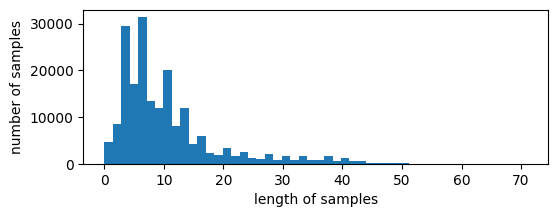

In [27]:
# 리뷰 길이 분포 확인
print('리뷰의 최대 길이 :',max(len(review) for review in tokenized_data))
print('리뷰의 평균 길이 :',sum(map(len, tokenized_data))/len(tokenized_data))
plt.figure(figsize=(6,2))
plt.hist([len(review) for review in tokenized_data], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

# W2V모델

In [28]:
from gensim.models import Word2Vec

model = Word2Vec(sentences = tokenized_data,
                 vector_size = 100, window = 5,
                 min_count = 5, workers = 4, sg = 0)

In [29]:
# 완성된 임베딩 매트릭스의 크기 확인
model.wv.vectors.shape

(16257, 100)

In [30]:
print(model.wv.most_similar("최민식"))

[('한석규', 0.8453003168106079), ('크리스찬', 0.8437197208404541), ('김수현', 0.8413782715797424), ('주진모', 0.8395834565162659), ('박중훈', 0.8373230695724487), ('이민호', 0.8359144330024719), ('이정재', 0.8357319235801697), ('설경구', 0.835227370262146), ('안성기', 0.8347893953323364), ('최민수', 0.8338841199874878)]


In [31]:
print(model.wv.most_similar("히어로"))

[('슬래셔', 0.8825980424880981), ('무협', 0.8566680550575256), ('호러', 0.8407546877861023), ('느와르', 0.8368683457374573), ('정통', 0.8245565891265869), ('물의', 0.8244368433952332), ('무비', 0.8158540725708008), ('블록버스터', 0.8079128265380859), ('판타지', 0.7888776063919067), ('블랙', 0.7885292172431946)]


# 사전 훈련된 Word2Vec 모델(Pre-trained Word2Vec embedding) 
* 모델 다운로드 경로 : https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit
* 압축 파일의 용량은 약 1.5GB이지만, 파일의 압축을 풀면 약 3.3GB의 파일이 나옵니다.

<pre>
데이터가 부족할때 사용(이미 학습된 모델이라 적은 데이터에서도 성능 좋음)
단어 집합의 일치(내가 분석하려는 언어와 도메인에 맞는 사전 훈련모델고르기)
단어의 수치화 방식 차이(모델마다 모르는 단어 처리하는 능력이 다름 ex. W2V : 모르는 단어 나오면 아예 대답 못함)

In [ ]:
# import gensim
# import urllib.request

# # 구글의 사전 훈련된 Word2Vec 모델을 로드.
# urllib.request.urlretrieve("https://s3.amazonaws.com/dl4j-distribution/GoogleNews-vectors-negative300.bin.gz", \
#                            filename="GoogleNews-vectors-negative300.bin.gz")
# word2vec_model = gensim.models.KeyedVectors.load_word2vec_format('GoogleNews-vectors-negative300.bin.gz', binary=True)

In [ ]:
# urllib.request.urlretrieve("https://s3.amazonaws.com/dl4j-distribution/GoogleNews-vectors-negative300.bin.gz", \    -> 여기서 다운안받고 모델 다운로드 경로로 받기 : https://drive.google.com/file/d/0B7XkCwpl5KDYNINUTTISS21pQmM/edit
#                            filename="GoogleNews-vectors-negative300.bin.gz")